In [1]:
from pathlib import Path

import pandas as pd

from weathergen.utils.plot_master import get_timeseries

In [2]:
runns = {
    "non-rad" : {
        "oj5auhkq": "base-6hx1_1x1453",
        "mir6d9d1": "small-6hx1_1x1453",
        "pld2v6hf": "small-tiny-6hx1_1x1453",
        "wew96c1e": "tiny-6hx1_1x1453",
    },
    "rad": {
        "g2rk8ymu": "small-6hx1_1x1453",
        "ez07q1jj": "small-tiny-6hx1_1x1453",
        "onslzyni": "tiny-6hx1_1x1453",
    },
    "new data": {
        
    }
}

In [3]:
results_dir = Path('/e/home/jusers/grasse1/jupiter/weatherai/WeatherGenerator/results')
file_name = "validation_chkpt00000_rank0000.zip"
results_dir.is_dir()

True

In [4]:
KELVIN = 273.15
import numpy as np

def plot_sample(target, prediction, channel: str):
    x, y = target.lon.values, target.lat.values
    targets = target.values - KELVIN
    preds = prediction.values - KELVIN

    mask = np.isnan(targets)
    preds[mask] = np.nan

    fig, axs = plt.subplots(ncols=3, nrows=1, subplot_kw={"projection": ccrs.Mollweide()})
    for ax, data in zip(axs, [targets, preds, targets - preds], strict=True):
        ax.coastlines()
        im = ax.scatter(x, y, c=data, cmap="viridis", s=0.5, alpha=0.5)
        # plt.colorbar(im)

def plot_fsteps(result_path, sample: int, stream: str):
    with io.zarrio_reader(results_path) as reader:
        for fstep in reader.forecast_steps[1:]:
            item = reader.get_data(sample, stream, fstep)


def contents(results_path):
    with io.zarrio_reader(results_path) as reader:
        print(
            sorted(int(fstep) for fstep in reader.forecast_steps),
            sorted(int(sample) for sample in reader.samples),
            reader.streams,
        )


In [5]:
def transform_index(ts):
    init_time = ts["source_interval_start"][1]
    ts.index = pd.DatetimeIndex(init_time + ts.index * pd.Timedelta("6h"), name="date")
    return ts

In [6]:
import dataclasses
@dataclasses.dataclass
class Run:
    id: str
    data: pd.Series
    label: str

averages = []
for run_id, label in zip(["wew96c1e", "pld2v6hf"], ["tiny-6hx1", "small-tiny-6hx1"]):
    results_path = results_dir / run_id / file_name
    averages.append(Run(
        run_id,
        transform_index(get_timeseries(results_path, "ERA5-Ocean", sample=0)),
        label
    ))

Text(0, 0.5, '$\\overline{sst}$ (K)')

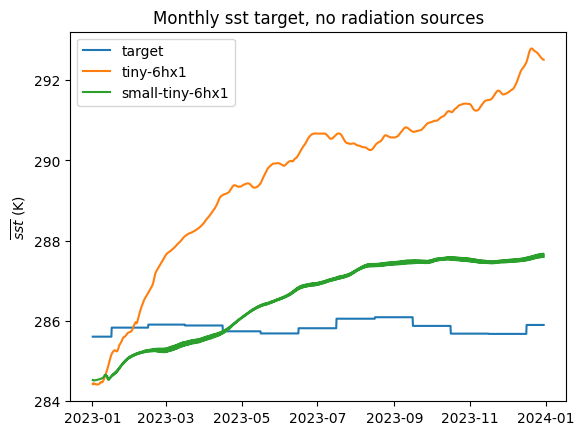

In [9]:
import matplotlib.pyplot as plt
ax = plt.subplot(1,1,1)
ax.plot(averages[0].data.index, averages[0].data.target, label="target")
for run in averages:
    ax.plot(run.data.index, run.data.prediction, label=run.label)
ax.legend()
ax.set_title("Monthly sst target, no radiation sources")
ax.set_ylabel("$\overline{sst}$ (K)")